In [ ]:
import sys
sys.path.append('../../')
import numpy as np

#test

from samrfi import RadioRFI, RFIDataset, RFITraining

/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from samrfi import RadioRFI

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

original_calib = '/home/gpuhost002/ddeal/RFI-AI/original_calib/calib_phase_rflag.ms'

datarfi_3C147 = RadioRFI(vis=original_calib, dir_path=dir_path)
datarfi_3C147.load(mode='DATA', ant_i=2) # using first two antennas


Loading data...


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [01:26<00:00, 43.06s/it]


(51, 4, 2048, 196)


In [3]:
datarfi_3C147.load(mode='FLAG', ant_i=2) # using first two antennas
datarfi_3C147.flags = np.abs(datarfi_3C147.ms_flags)


Loading data...


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:36<00:00, 18.39s/it]


In [4]:
# datarfi_3C147.rfi_antenna_data = datarfi_3C147.rfi_antenna_data[0:2]
# datarfi_3C147.flags = datarfi_3C147.flags[0:2]

In [5]:
datarfi_3C147.rfi_antenna_data.shape

(51, 4, 2048, 196)

In [6]:
datarfi_3C147.flags.shape

(51, 4, 2048, 196)

In [7]:
reflected_part = np.flip(datarfi_3C147.rfi_antenna_data, axis=-1)  # Alternatively, use arr[..., ::-1]
# Step 2: Concatenate along the last axis
new_arr = np.concatenate((datarfi_3C147.rfi_antenna_data, reflected_part), axis=-1)
datarfi_3C147.rfi_antenna_data = new_arr

datarfi_3C147.flags = np.abs(datarfi_3C147.ms_flags)

reflected_part = np.flip(datarfi_3C147.flags, axis=-1)  # Alternatively, use arr[..., ::-1]
# Step 2: Concatenate along the last axis
new_arr = np.concatenate((datarfi_3C147.flags, reflected_part), axis=-1)
datarfi_3C147.flags = new_arr

In [8]:
datarfi_3C147.flags.shape, datarfi_3C147.rfi_antenna_data.shape


((51, 4, 2048, 392), (51, 4, 2048, 392))

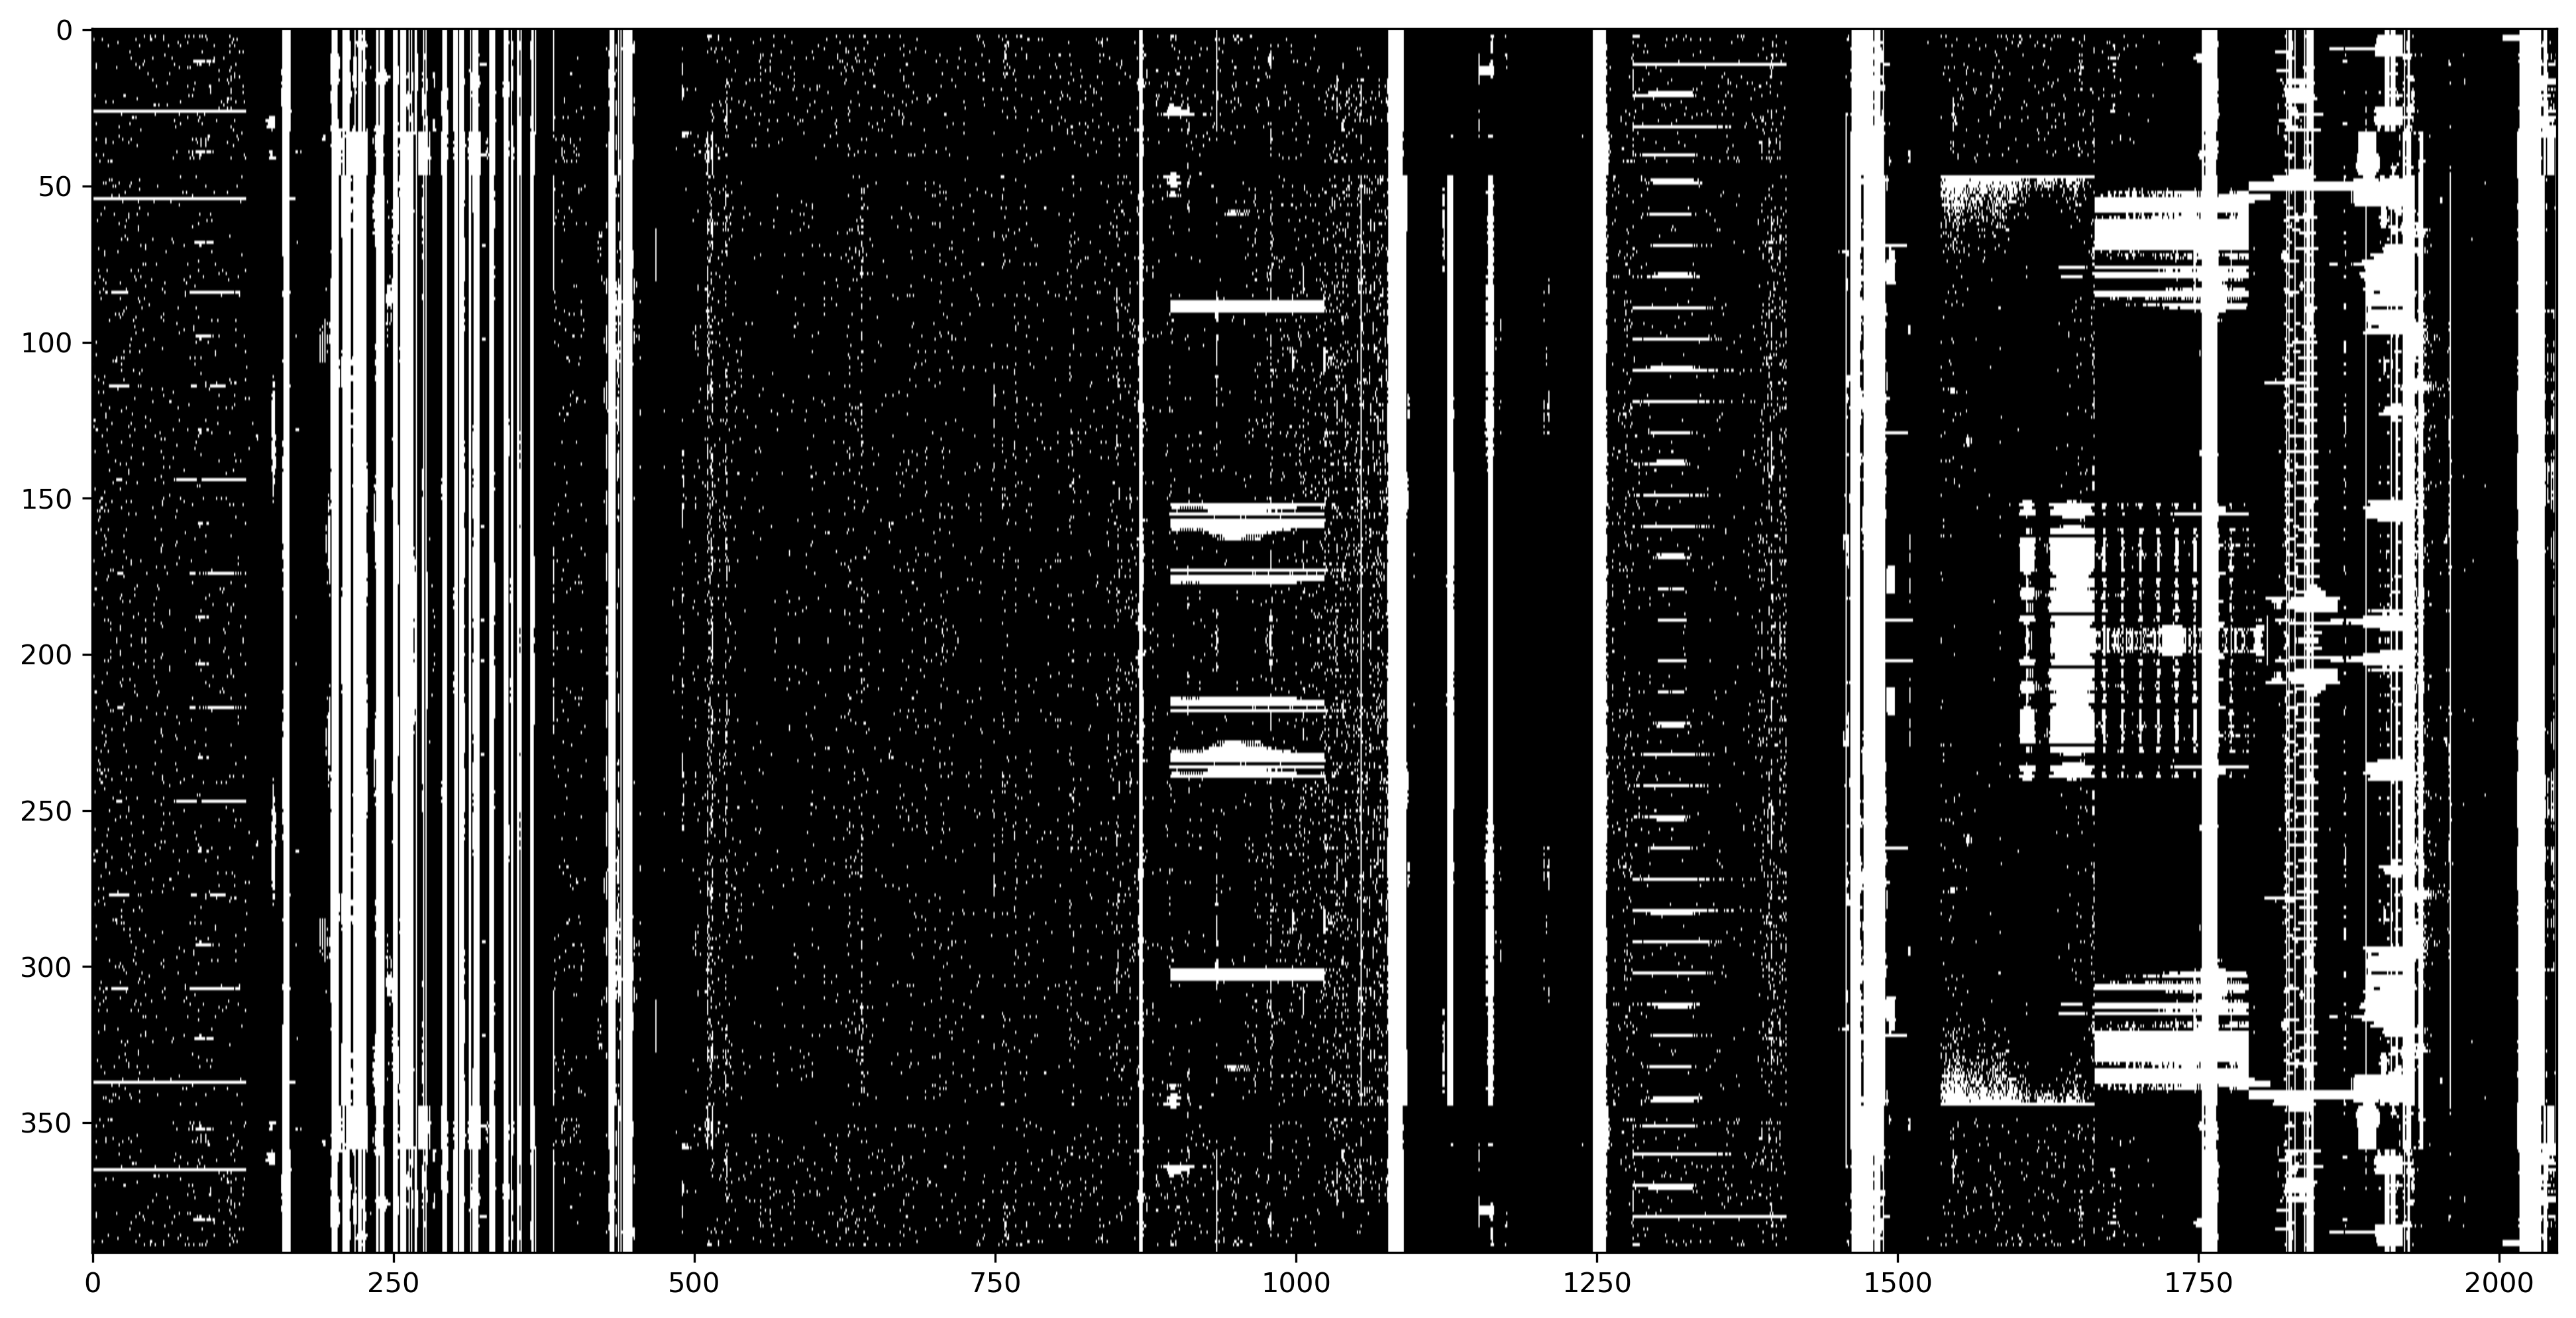

In [15]:
datarfi_3C147.plotter.plot(mode='FLAG', baseline=0, polarization=0)

In [9]:
rfi_dataset = RFIDataset(datarfi_3C147, dir_path=dir_path)
rfi_dataset.create_dataset(num_patches=600, patch_size=256, apply_stretching=True, custom_flag=False)


Applying median normalization only to 6528 patches...


100%|██████████| 6528/6528 [00:07<00:00, 928.86it/s]



Applying SQRT stretch and normalization to 6528 patches...


100%|██████████| 6528/6528 [00:14<00:00, 450.89it/s]



Applying median normalization only to 6528 patches...


100%|██████████| 6528/6528 [00:07<00:00, 931.34it/s]



Creating sigma 5 flags for each data patch...


100%|██████████| 6528/6528 [00:15<00:00, 421.06it/s]


(6500, 256, 256) (6500, 256, 256)


In [10]:
cd /home/gpuhost002/ddeal/RFI-AI/sam2/notebooks

/home/gpuhost002/ddeal/RFI-AI/sam2/notebooks


/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/gpuhost002/ddeal/RFI-AI/SAM-RFI/notebooks/test_notebooks/../../samrfi/rfitraining.py:222: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/home/gpuhost002/ddeal/RFI-AI/SAM-RFI/notebooks/test_notebooks/../../samrfi/rfitraining.py:238: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



Training SAM 2 model...


0it [00:00, ?it/s]/home/gpuhost002/ddeal/RFI-AI/SAM-RFI/notebooks/test_notebooks/../../samrfi/rfitraining.py:292: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
600it [01:13,  8.13it/s]
/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 2/40, Loss: 0.38208595586319766


600it [01:14,  8.01it/s]


...

600it [01:12,  8.32it/s]


Epoch 40/40, Loss: 0.007135065595988029


600it [01:12,  8.33it/s]


Epoch 41/40, Loss: 0.006693638416618341


<Figure size 640x480 with 0 Axes>

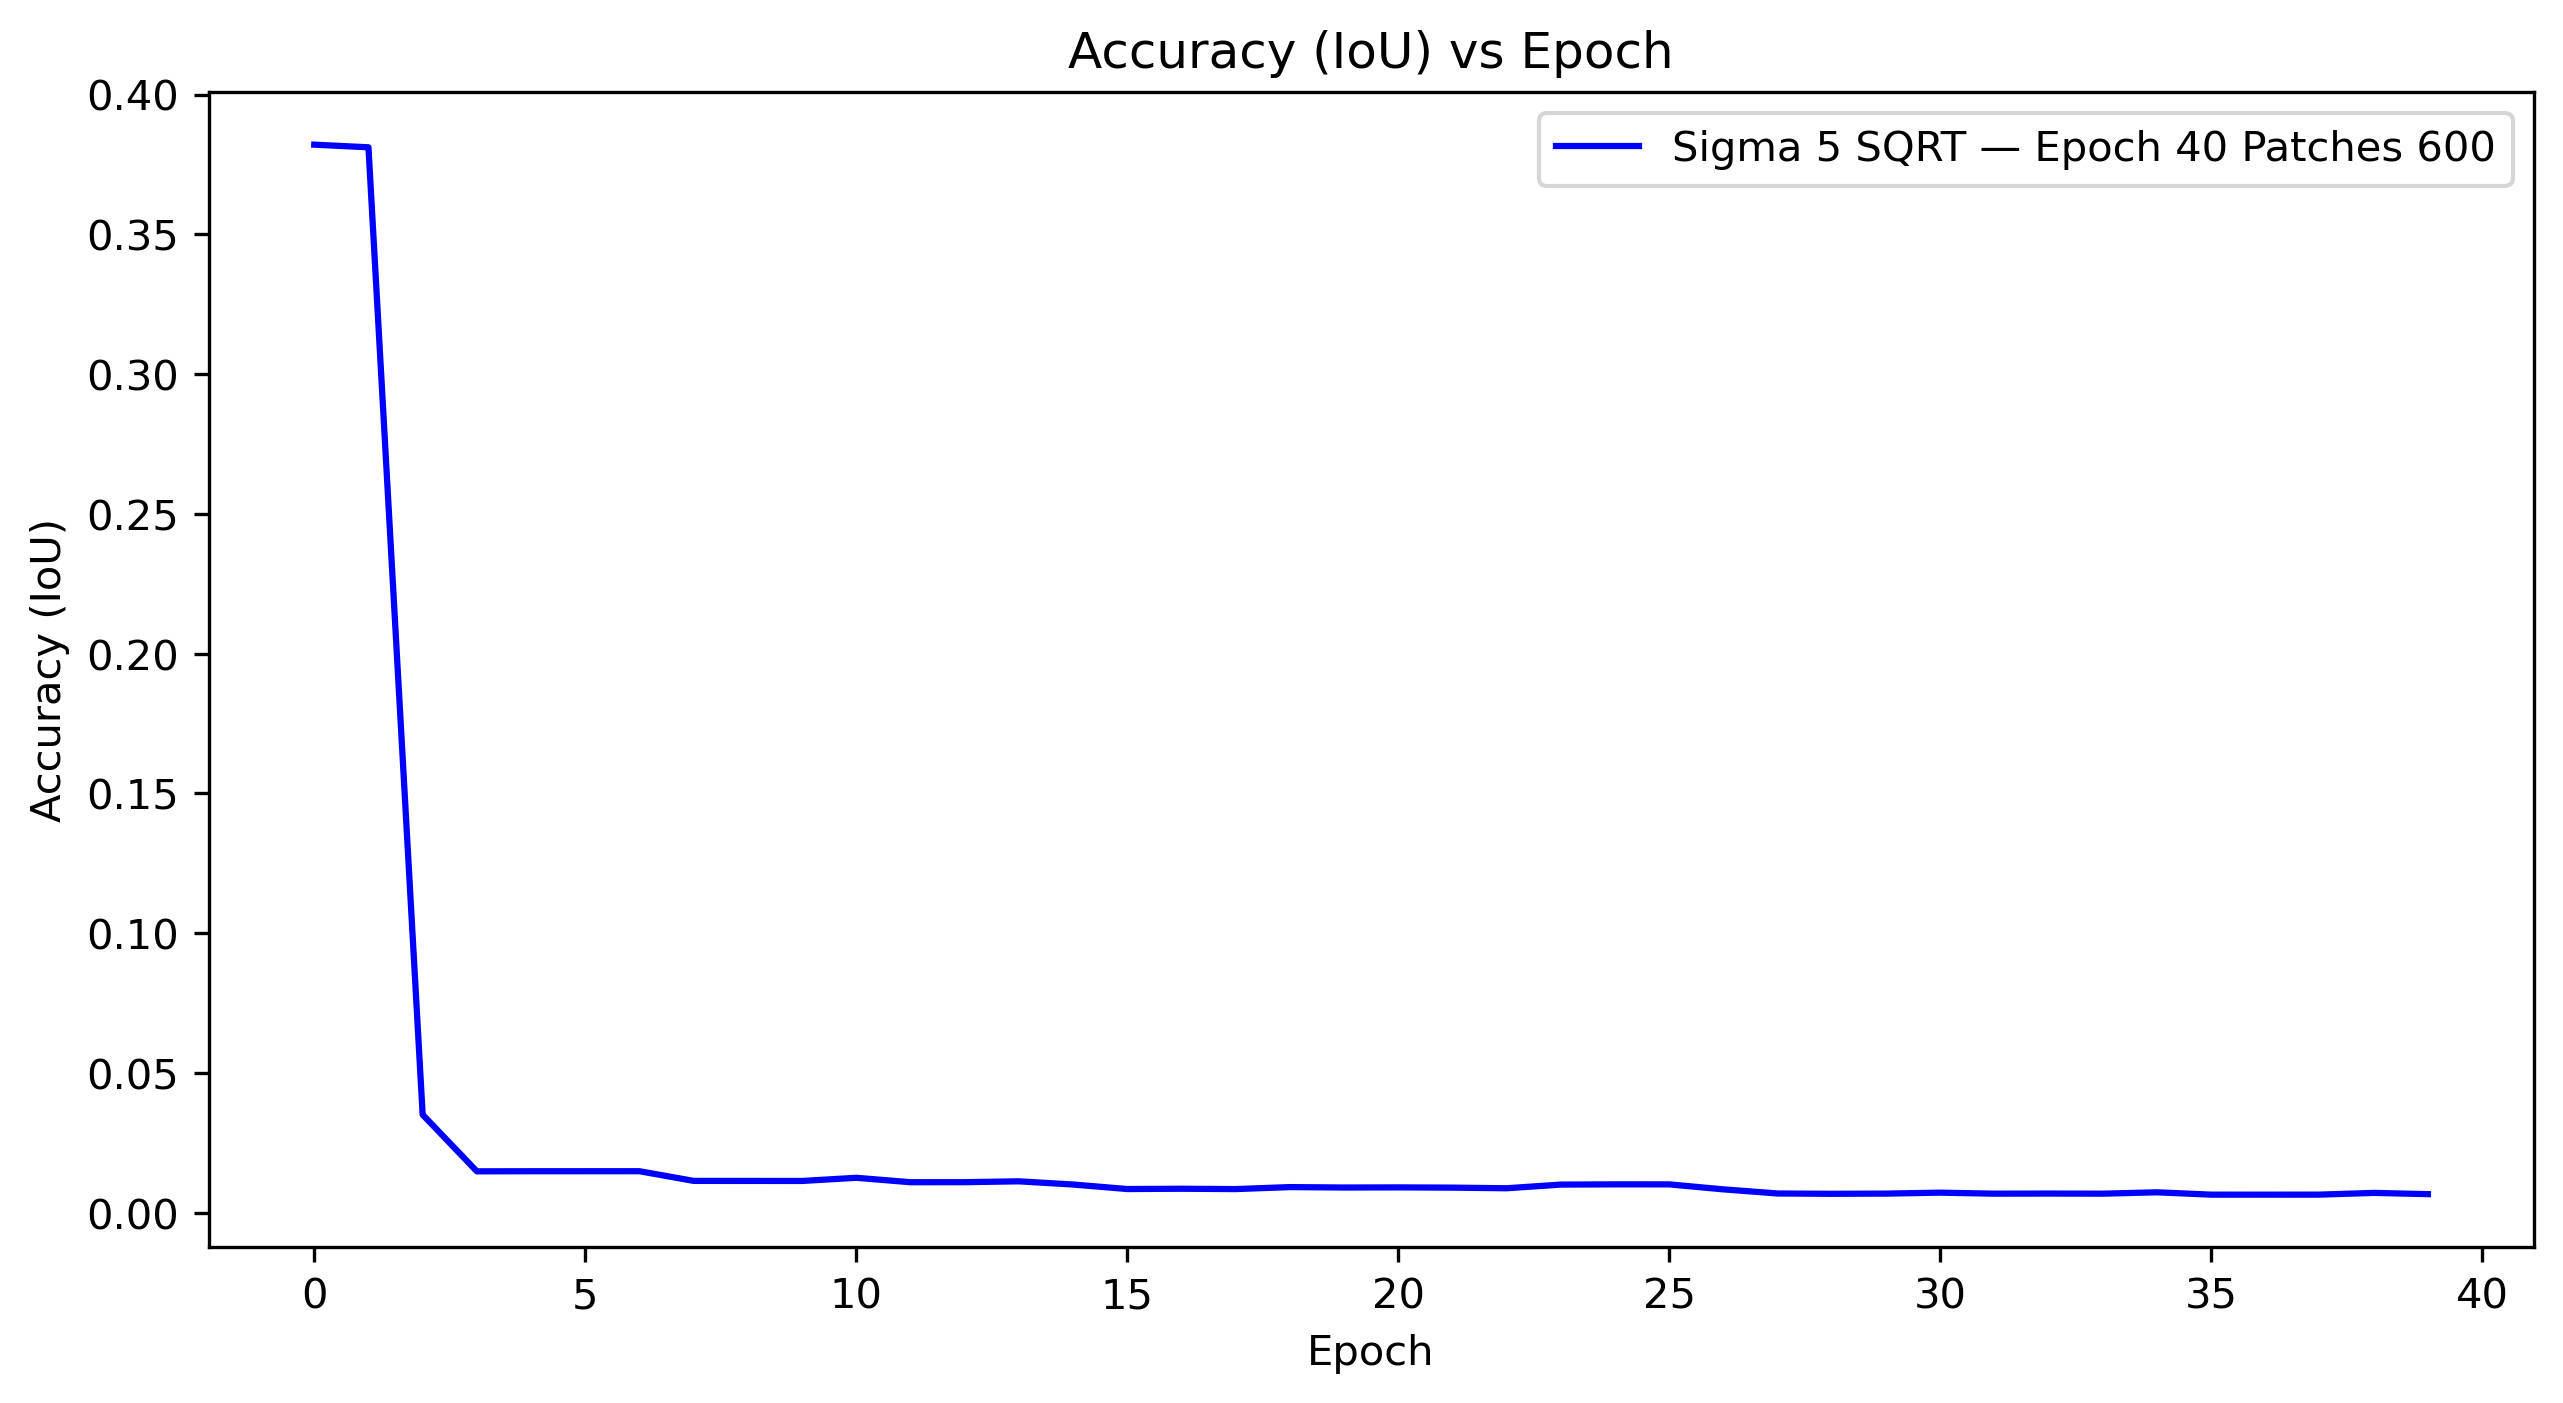

In [11]:
new_model_sam2 = RFITraining(rfi_dataset, device='cuda', dir_path=dir_path)

new_model_sam2.sam2_ckpt = "../checkpoints/sam2.1_hiera_large.pt"
new_model_sam2.sam2_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
new_model_sam2.train_sam2(num_epochs=40, batch_size=None, step_size=500, num_points=256)

In [ ]:
# /home/gpuhost002/ddeal/RFI-AI/samrfi_data/models/model_stretch-SQRT_sigma-5_patch-patchify_size-256_sam2-small_epochs40_20250108_004244.pth

AttributeError: 'RFITraining' object has no attribute 'test_mask'

In [14]:
# new_model_sam2.gt_mask.shape, new_model_sam2.prd_mask.shape
# new_model_sam2.prd_mask = 1 - new_model_sam2.prd_mask


In [15]:
# binary_gt_mask = (new_model_sam2.prd_mask > 0.95)

In [16]:
plt.imshow(.to('cpu').detach().numpy())
plt.colorbar()

SyntaxError: invalid syntax (3936629507.py, line 1)

In [26]:
new_model_sam2.gt_mask.float().max()

tensor(1., device='cuda:0')

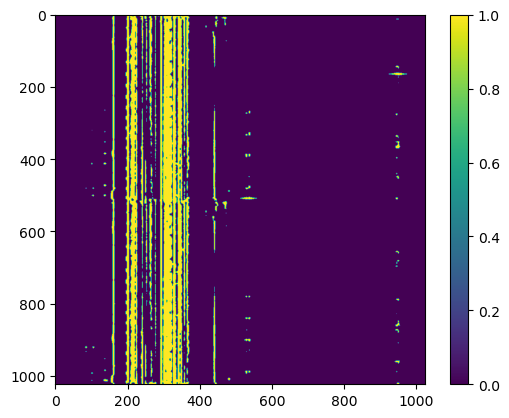

In [18]:
import matplotlib.pyplot as plt 

plt.imshow(new_model_sam2.prd_mask.to('cpu').detach().numpy()>0.95)
plt.colorbar()

In [16]:
map = new_model_sam2.prd_mask.to('cpu').detach().numpy()
map_gt = new_model_sam2.gt_mask.to('cpu').detach().numpy()

In [17]:
map.max()

True

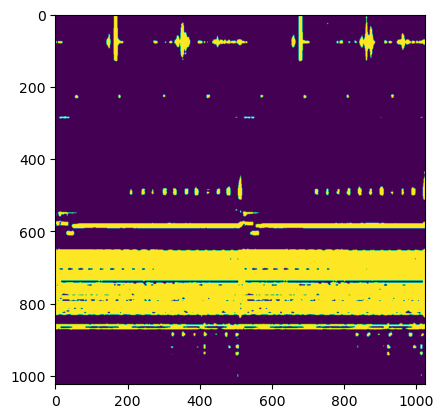

In [20]:
plt.imshow(map)

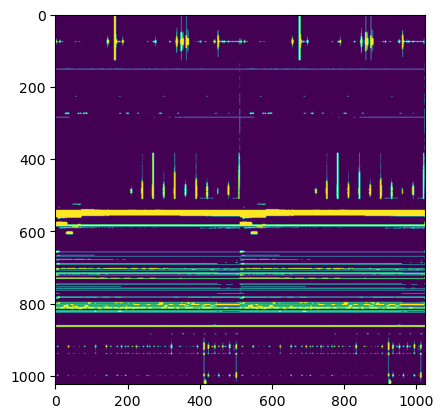

In [19]:
plt.imshow(map_gt)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [ ]:

plt.imshow(new_model_sam2.gt_mask.to('cpu').detach().numpy())